In [4]:
# --- PART A ---
import pandas as pd
import sqlite3

results = pd.read_csv('https://raw.githubusercontent.com/martj42/international_results/master/results.csv')
shootouts = pd.read_csv('https://raw.githubusercontent.com/martj42/international_results/master/shootouts.csv')

conn = sqlite3.connect(':memory:')
results.to_sql('results', conn, index=False, if_exists='replace')
shootouts.to_sql('shootouts', conn, index=False, if_exists='replace')

675

In [2]:
results1 = pd.read_sql("""
    SELECT *
    FROM results
""", conn)

results1

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,0
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,0
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,0
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,0
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,0
...,...,...,...,...,...,...,...,...,...
49210,2026-03-31,Kosovo,Turkey,0,1,FIFA World Cup qualification,Pristina,Kosovo,0
49211,2026-03-31,Czech Republic,Denmark,2,2,FIFA World Cup qualification,Prague,Czech Republic,0
49212,2026-03-31,Cameroon,China PR,2,0,FIFA Series,Melbourne,Australia,1
49213,2026-03-31,Australia,Curaçao,5,1,FIFA Series,Melbourne,Australia,0


In [3]:
shootouts1 = pd.read_sql("""
    SELECT *
    FROM shootouts
""", conn)

shootouts1

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,None
1,1971-11-14,South Korea,Vietnam Republic,South Korea,None
2,1972-05-07,South Korea,Iraq,Iraq,None
3,1972-05-17,Thailand,South Korea,South Korea,None
4,1972-05-19,Thailand,Cambodia,Thailand,None
...,...,...,...,...,...
670,2026-03-30,Cape Verde,Finland,Cape Verde,Cape Verde
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon,None
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan,None
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina,Bosnia and Herzegovina


In [7]:
# --- PART B ---
# B1:
b1 = pd.read_sql("""
    SELECT SUBSTR(date, 1, 3) || '0s' AS decade,
       COUNT(*) AS total_matches
    FROM results
    GROUP BY decade
    ORDER BY decade ASC
""", conn)

b1

,decade,total_matches
0,1870s,13
1,1880s,55
2,1890s,59
3,1900s,137
4,1910s,330
5,1920s,828
6,1930s,1079
7,1940s,833
8,1950s,1651
9,1960s,2971


In [6]:
# B2: 
b2 = pd.read_sql("""
    SELECT 
        CASE
            WHEN home_score > away_score THEN 'Home Win'
            WHEN home_score < away_score THEN 'Away Win'
            ELSE 'Draw'
        END AS result,
        COUNT(*) AS total
    FROM results
    GROUP BY result
""", conn)

b2

,result,total
0,Away Win,13912
1,Draw,11197
2,Home Win,24106


In [8]:
# B3:
b3 = pd.read_sql(""" 
    SELECT home_team, away_team, COUNT(*) AS matches_played
    FROM results
    GROUP BY home_team, away_team
    ORDER BY matches_played DESC
    LIMIT 10
""", conn)

b3

,home_team,away_team,matches_played
0,Argentina,Uruguay,99
1,Uruguay,Argentina,84
2,Austria,Hungary,69
3,Hungary,Austria,68
4,Kenya,Uganda,66
5,Argentina,Paraguay,65
6,Belgium,Netherlands,65
7,Netherlands,Belgium,64
8,Brazil,Paraguay,61
9,Argentina,Brazil,60


In [12]:
# B4:
b4 = pd.read_sql("""
    SELECT date, home_team, away_team, home_score
    FROM results
    WHERE home_score >= 5
    AND away_team IN (SELECT DISTINCT home_team FROM results)
    LIMIT 10
""", conn)

b4

,date,home_team,away_team,home_score
0,1878-03-02,Scotland,England,7
1,1878-03-23,Scotland,Wales,9
2,1879-04-05,England,Scotland,5
3,1880-03-13,Scotland,England,5
4,1880-03-27,Scotland,Wales,5
5,1882-02-25,Wales,Northern Ireland,7
6,1882-03-11,Scotland,England,5
7,1882-03-13,Wales,England,5
8,1882-03-25,Scotland,Wales,5
9,1883-02-03,England,Wales,5


In [18]:
# B5:
b5 = pd.read_sql("""
    SELECT tournament, ROUND(AVG(home_score + away_score), 2) AS total_goals_avg
    FROM results
    GROUP BY tournament
    HAVING COUNT(*) > 100 
    ORDER BY total_goals_avg DESC
    LIMIT 10
""", conn)

b5  

,tournament,total_goals_avg
0,South Pacific Games,5.91
1,CCCF Championship,4.46
2,Muratti Vase,4.35
3,CONIFA World Football Cup,4.20
4,Central European International Cup,4.19
5,Oceania Nations Cup,4.15
6,Island Games,3.98
7,EAFF Championship,3.85
8,Nordic Championship,3.84
9,British Home Championship,3.52


--- PART C ---
1. Looking at B1 — what trend do you notice in international football over the decades, and what might explain it?
   
The total number of international matches has grown consistently over the decades. There is a noticeable dip in the 1940s, which can be directly linked to World War II — with much of the world in conflict, international football was largely suspended. After the war, numbers recovered and grew steadily through the second half of the 20th century, reflecting the global expansion of football and the creation of new national teams as countries gained independence. The 2020s appear lower than the 2010s, but this is not a real decline — the decade is only 6 years old in this dataset, so we are simply seeing fewer years of data compared to every other complete decade.

2. In B2 — does the home win percentage surprise you, given what you saw in B2 from yesterday's exercise?

It definitely doesn't surprise me. Yesterday's data showed that home teams average 1.76 goals per match compared to 1.18 for away teams. It follows naturally from that scoring gap that home teams win almost double the number of matches that away teams do (24,106 vs 13,912). Both queries are telling the same story from different angles — home advantage in international football is real and significant.

3. In your own words, what does the subquery in B4 do, and why couldn't you solve it with just a simple WHERE clause?

The outer query selects date, home_team, away_team, and home_score from results, filtering to matches where the home team scored 5 or more goals. The second condition — that the away team must have also appeared as a home team somewhere in the dataset — cannot be solved with a simple WHERE clause. A simple WHERE can only compare a value against a fixed condition like >= 5. It cannot dynamically ask "does this value appear somewhere else in the table?" To answer that, you first need the subquery to build the complete list of all teams that have ever been a home team, and then the outer query checks whether each away team appears in that list using IN.

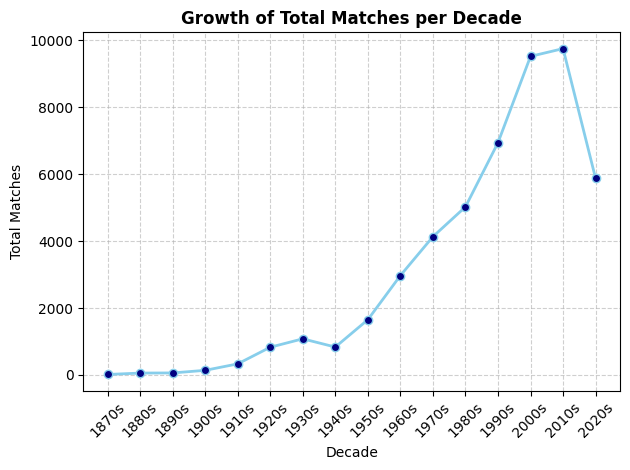

In [17]:
# --- PART D ---
import matplotlib.pyplot as plt

# Plotting the data
plt.plot(b1['decade'], b1['total_matches'], color='skyblue', marker='o', 
         linewidth=2, markersize=6, markerfacecolor='navy')

# Labels and Title
plt.xlabel('Decade')
plt.ylabel('Total Matches')
plt.title('Growth of Total Matches per Decade', fontsize=12, fontweight='bold')

# Readability & Aesthetics
plt.grid(True, linestyle='--', alpha=0.6) 
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()